In [2]:
from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from GridReconstruction import GridReconstructionNetwork
from GridReconstruction import GridReconstruction
from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')

In [3]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="FixedGridDataset",
                                         representation_folder_name="grids", num_workers=2)

In [7]:
lightning_model = GridReconstruction.load_from_checkpoint("SmallBottleneck.ckpt", weight_opacity=False, small_bottleneck=True, double_channels=False)
model = lightning_model.model
model.eval()
model = model.cpu()

In [8]:
test_dataset = dataset_loader.test_dataloader().dataset

In [9]:
representation, idx_tensors, vals_tensor, colour_tensor, directions = test_dataset.get_testing_items(2)

In [10]:
test_dataset.piece_names[2]

'RPf_00206.npz'

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

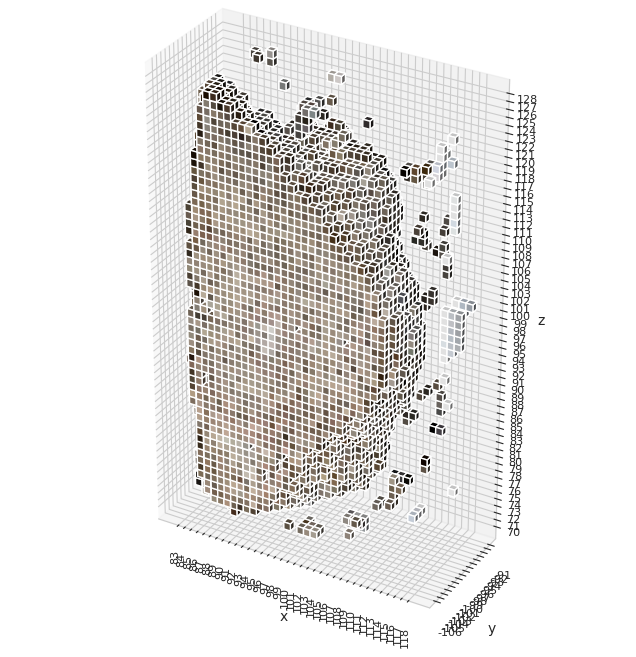

In [11]:
plot_colored_voxels(idx_tensors, colour_tensor)

In [13]:
with torch.no_grad():
    reconstructed_grid = model(representation.unsqueeze(0)).squeeze(0)

In [14]:
weights = reconstructed_grid[-1]

In [15]:
weights.shape

torch.Size([200, 200, 200])

In [16]:
r_idx_tensors = torch.where(weights > 0.3)

In [17]:
r_idx_tensors[0].shape[0]

10129

In [18]:
random_directions = F.normalize(torch.randn((r_idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent = reconstructed_grid[:-1, r_idx_tensors[0], r_idx_tensors[1], r_idx_tensors[2]].T
r_colours = test_dataset.latent2representation.get_colour_from_latent(latent, random_directions).detach()


In [19]:
random_directions2 = F.normalize(torch.randn((idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent2 = representation[:-1, idx_tensors[0], idx_tensors[1], idx_tensors[2]].T
r_colours2 = test_dataset.latent2representation.get_colour_from_latent(latent2, random_directions2).detach()


In [20]:
r_colours

tensor([[0.1701, 0.0442, 0.1710],
        [0.1669, 0.0364, 0.1575],
        [0.1841, 0.0556, 0.1790],
        ...,
        [0.1666, 0.0779, 0.1927],
        [0.1809, 0.0805, 0.1980],
        [0.1637, 0.0727, 0.1884]])

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

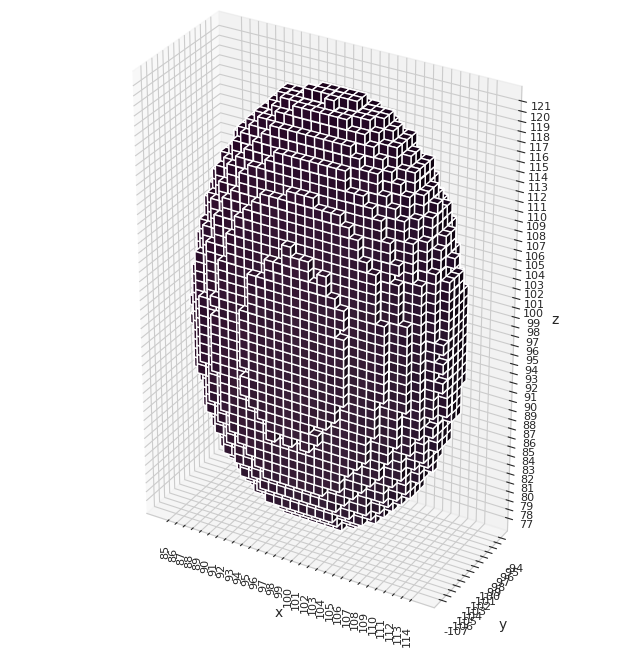

In [21]:
plot_colored_voxels(r_idx_tensors, r_colours)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

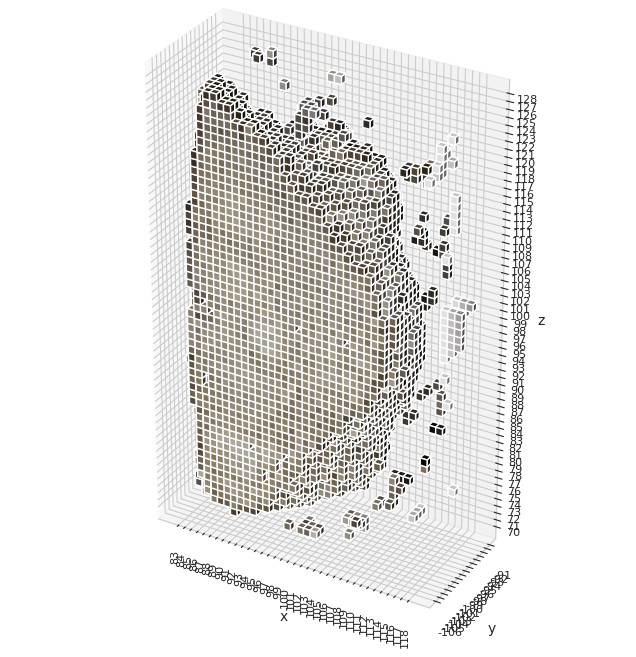

In [22]:
plot_colored_voxels(idx_tensors, r_colours2)


59


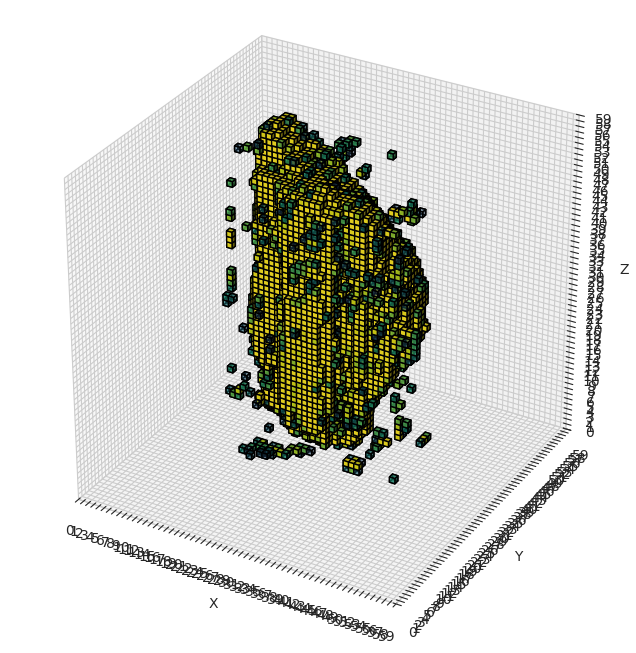

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(71, 130, None), slice(69, 128, None), slice(70, 129, None)))

In [23]:
plot_opacity_tensor(representation[-1], threshold=0.3)

62


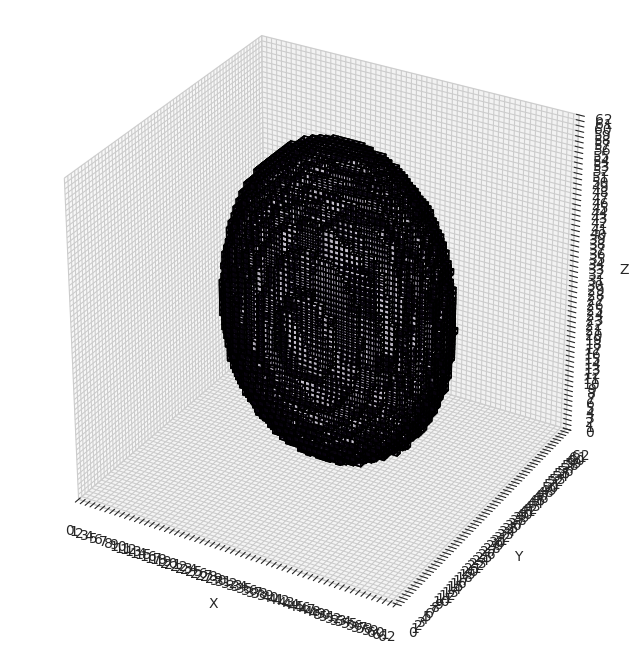

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(68, 130, None), slice(69, 131, None), slice(68, 130, None)))

In [24]:
plot_opacity_tensor(reconstructed_grid[-1], threshold=0.1)
